## Cell Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
os.makedirs("../reports/eda_plots", exist_ok=True)

## Load and drop columns

In [3]:
df = pd.read_csv("../data/raw/ai_jobs_market.csv")

cols_to_drop = [
    "job_category", "city", "required_skills",
    "ai_salary_premium_pct", "demand_score", "demand_growth_yoy_pct",
    "benefits_score_10", "posting_year", "posting_month",
    "is_senior", "is_remote_friendly", "is_llm_role"
]

df.drop(columns=cols_to_drop, inplace=True)

print(df.shape)
print(df.columns.tolist())

(1500, 9)
['job_title', 'experience_level', 'years_of_experience', 'education_required', 'annual_salary_usd', 'country', 'remote_work', 'company_size', 'industry']


## Basic Info and Null Check

In [4]:
print(df.info())
print()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_title            1500 non-null   str    
 1   experience_level     1500 non-null   str    
 2   years_of_experience  1500 non-null   int64  
 3   education_required   1500 non-null   str    
 4   annual_salary_usd    1500 non-null   float64
 5   country              1500 non-null   str    
 6   remote_work          1500 non-null   str    
 7   company_size         1500 non-null   str    
 8   industry             1500 non-null   str    
dtypes: float64(1), int64(1), str(7)
memory usage: 224.0 KB
None

job_title              0
experience_level       0
years_of_experience    0
education_required     0
annual_salary_usd      0
country                0
remote_work            0
company_size           0
industry               0
dtype: int64


In [5]:
df[["years_of_experience", "annual_salary_usd"]].describe().round(2)

,years_of_experience,annual_salary_usd
count,1500.00,1500.00
mean,6.22,194892.00
std,2.68,66506.82
min,1.00,90000.00
25%,4.00,144750.00
50%,6.00,180000.00
75%,8.00,236250.00
max,15.00,384000.00


## Salary Distribution

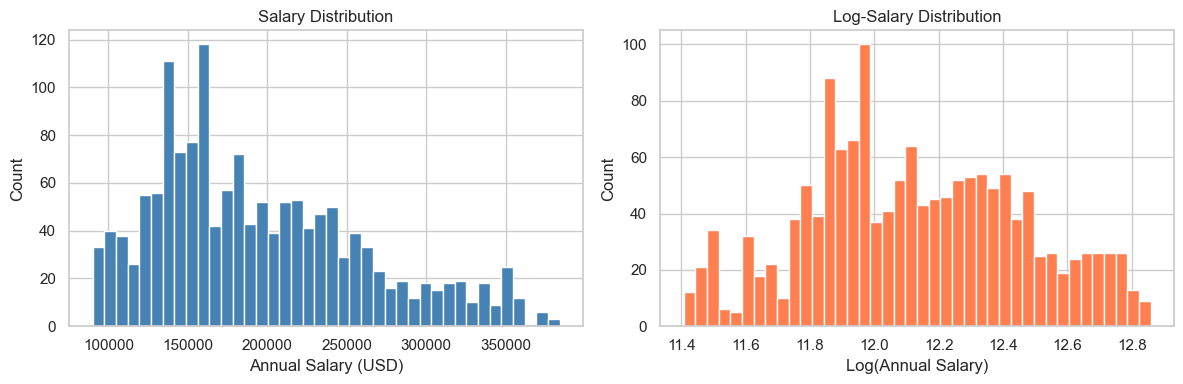

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["annual_salary_usd"], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Salary Distribution")
axes[0].set_xlabel("Annual Salary (USD)")
axes[0].set_ylabel("Count")

axes[1].hist(np.log(df["annual_salary_usd"]), bins=40, color="coral", edgecolor="white")
axes[1].set_title("Log-Salary Distribution")
axes[1].set_xlabel("Log(Annual Salary)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../reports/eda_plots/salary_distribution.png", dpi=150)
plt.show()

## Salary by Experience Level

C:\Users\bibek\AppData\Local\Temp\ipykernel_15028\2863699513.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="experience_level", y="annual_salary_usd", order=order, palette="Blues")


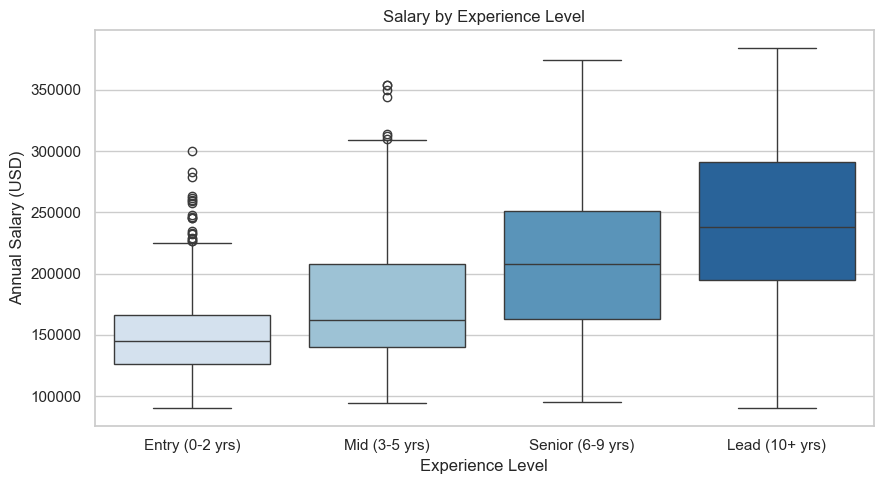

In [7]:
order = ["Entry (0-2 yrs)", "Mid (3-5 yrs)", "Senior (6-9 yrs)", "Lead (10+ yrs)"]

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="experience_level", y="annual_salary_usd", order=order, palette="Blues")
plt.title("Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Annual Salary (USD)")
plt.tight_layout()
plt.savefig("../reports/eda_plots/salary_by_experience_level.png", dpi=150)
plt.show()

## Salary by Country

C:\Users\bibek\AppData\Local\Temp\ipykernel_15028\2827433098.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="country", y="annual_salary_usd", order=country_order, palette="Set2")


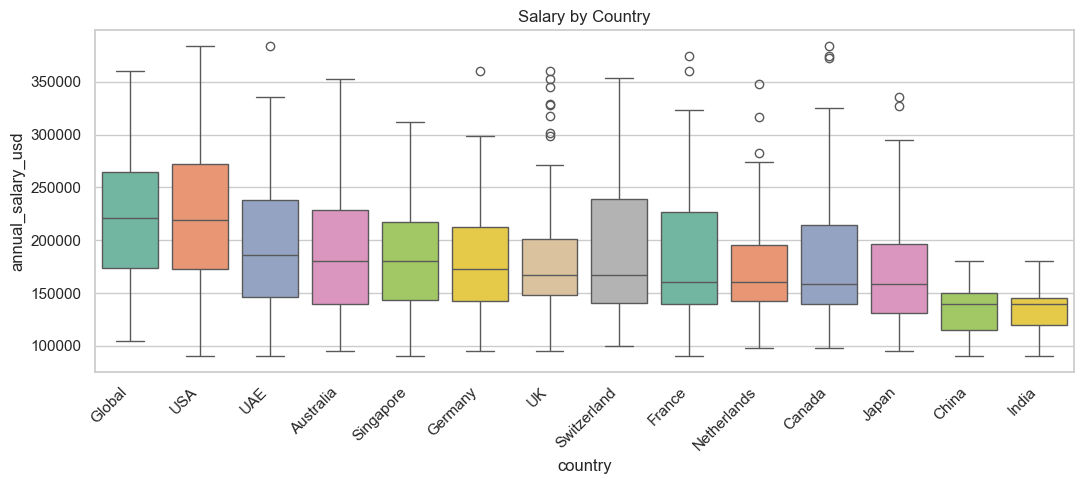

In [8]:
country_order = df.groupby("country")["annual_salary_usd"].median().sort_values(ascending=False).index

plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x="country", y="annual_salary_usd", order=country_order, palette="Set2")
plt.title("Salary by Country")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../reports/eda_plots/salary_by_country.png", dpi=150)
plt.show()

## Salary by Company Size

C:\Users\bibek\AppData\Local\Temp\ipykernel_15028\408873096.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="company_size", y="annual_salary_usd", order=size_order, palette="Purples")


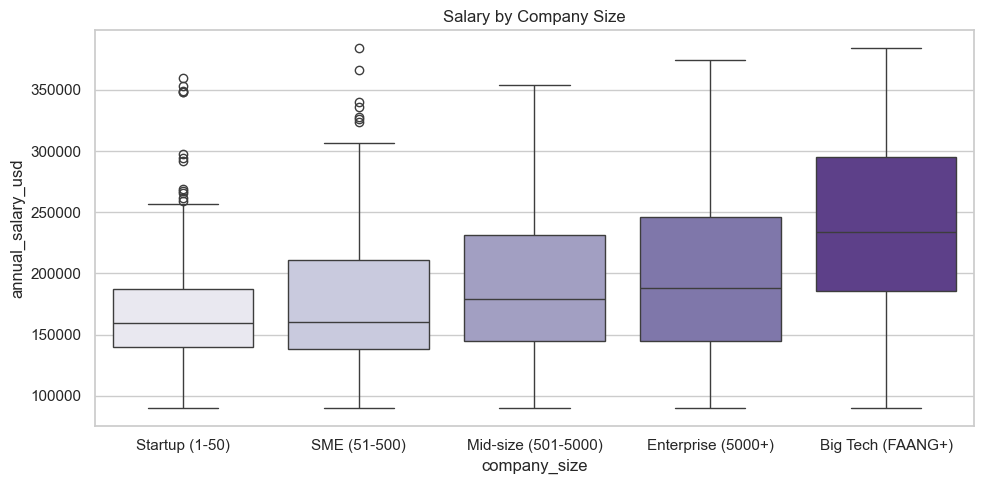

In [9]:
size_order = [
    "Startup (1-50)", "SME (51-500)", "Mid-size (501-5000)",
    "Enterprise (5000+)", "Big Tech (FAANG+)"
]

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="company_size", y="annual_salary_usd", order=size_order, palette="Purples")
plt.title("Salary by Company Size")
plt.tight_layout()
plt.savefig("../reports/eda_plots/salary_by_company_size.png", dpi=150)
plt.show()

## Salary VS Years of experience

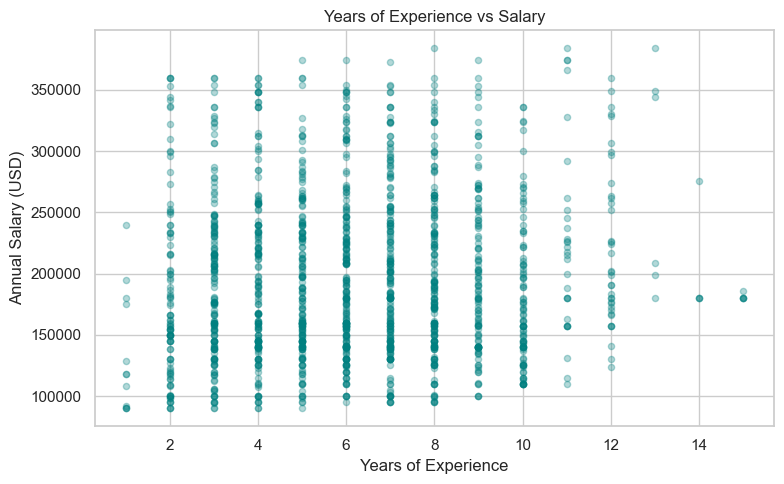

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(df["years_of_experience"], df["annual_salary_usd"], alpha=0.3, color="teal", s=20)
plt.title("Years of Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Annual Salary (USD)")
plt.tight_layout()
plt.savefig("../reports/eda_plots/experience_vs_salary_scatter.png", dpi=150)
plt.show()

## Categorical Value Counts

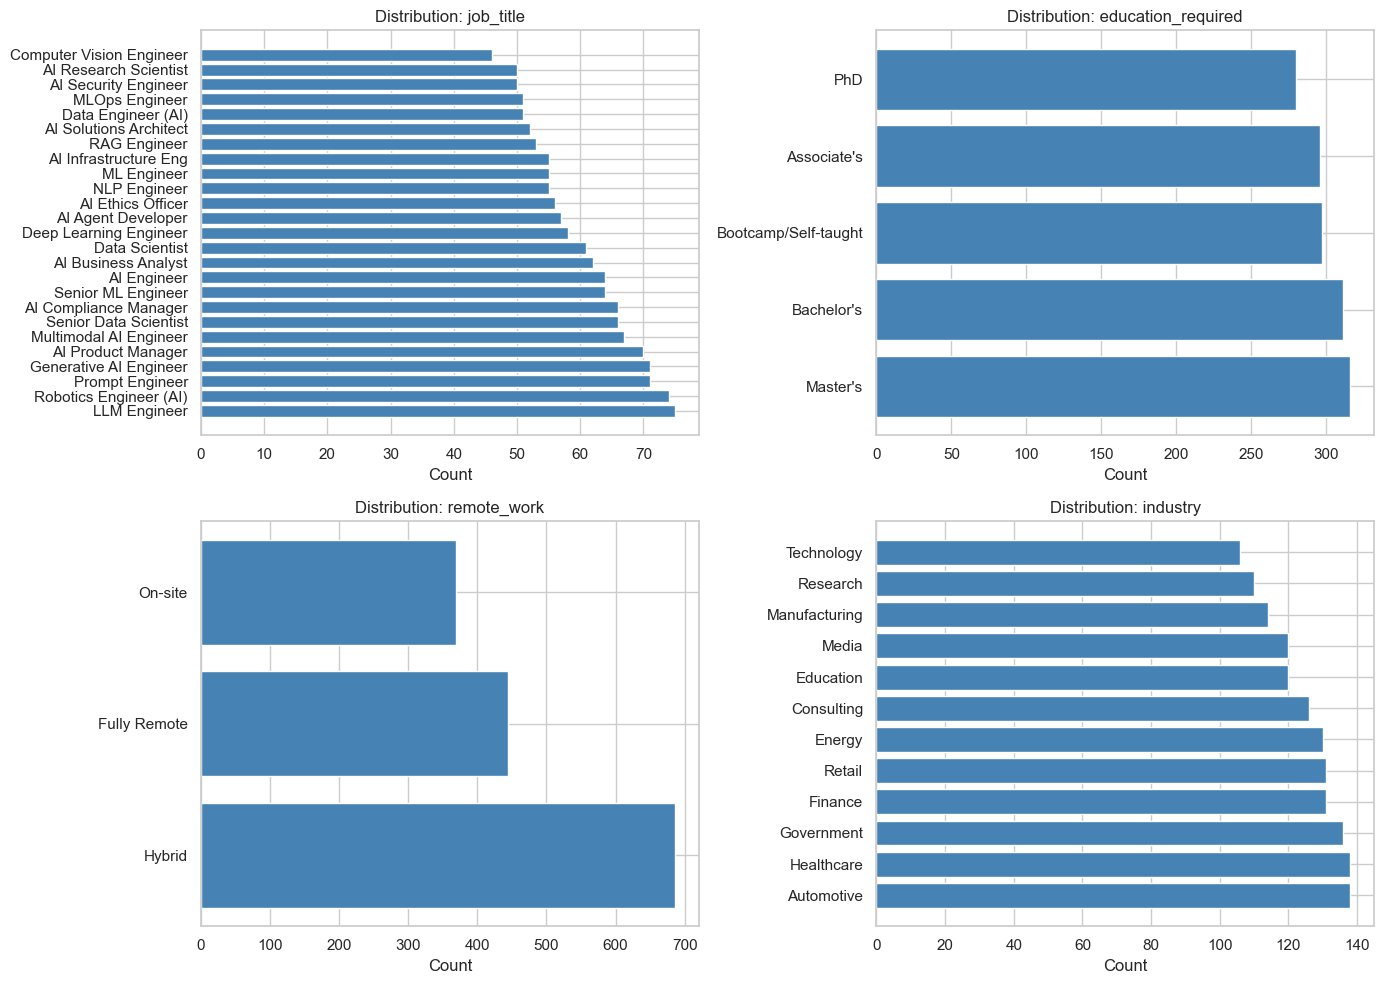

In [11]:
cat_cols = ["job_title", "education_required", "remote_work", "industry"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), cat_cols):
    counts = df[col].value_counts()
    ax.barh(counts.index, counts.values, color="steelblue")
    ax.set_title(f"Distribution: {col}")
    ax.set_xlabel("Count")

plt.tight_layout()
plt.savefig("../reports/eda_plots/categorical_distributions.png", dpi=150)
plt.show()

## Salary By Job Title

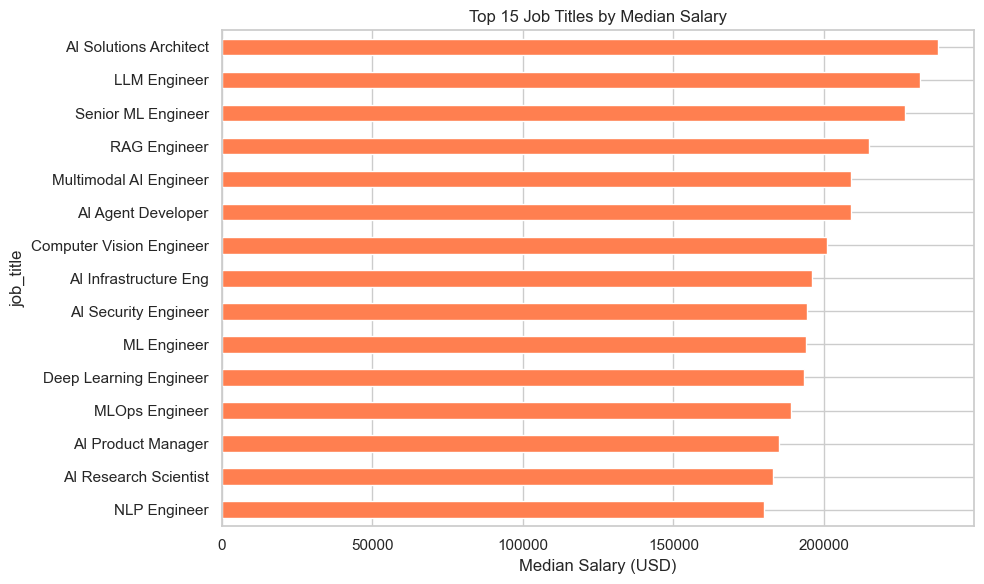

In [12]:
top_titles = df.groupby("job_title")["annual_salary_usd"].median().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_titles.plot(kind="barh", color="coral")
plt.title("Top 15 Job Titles by Median Salary")
plt.xlabel("Median Salary (USD)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../reports/eda_plots/salary_by_job_title_top15.png", dpi=150)
plt.show()

## Correlation Heatmap

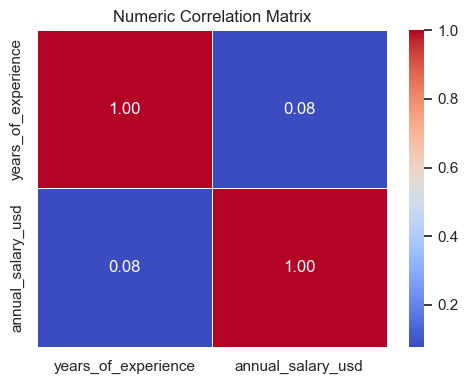

In [13]:
plt.figure(figsize=(5, 4))
corr = df[["years_of_experience", "annual_salary_usd"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Numeric Correlation Matrix")
plt.tight_layout()
plt.savefig("../reports/eda_plots/correlation_heatmap.png", dpi=150)
plt.show()

# Saving the working DF

In [14]:
df.to_csv("../data/processed/cleaned.csv", index=False)
print("Saved cleaned.csv with shape:", df.shape)

Saved cleaned.csv with shape: (1500, 9)


# EDA Summary — AI Job Market Salary Prediction

## Dataset Overview

The working dataset after dropping irrelevant columns contains **1,500 rows and 9 columns**.
All 9 columns are fully populated with zero null values, so no imputation was needed at any stage.

The 9 retained columns are: `job_title`, `experience_level`, `years_of_experience`,
`education_required`, `annual_salary_usd`, `country`, `remote_work`, `company_size`, `industry`.

---

## Target Variable — annual_salary_usd

| Statistic | Value |
|-----------|-------|
| Mean | $194,892 |
| Median | $180,000 |
| Std Dev | $66,507 |
| Min | $90,000 |
| Max | $384,000 |
| Skewness | 0.72 |

The salary distribution is moderately right-skewed (skewness = 0.72), meaning a tail of
high-paying roles pulls the mean above the median. This is typical of tech salary data.
A log transform was flagged here and applied in Notebook 2 to bring the distribution
closer to normal before modelling.

---

## Numeric Feature — years_of_experience

Experience in the dataset ranges from 1 to 15 years with a mean of 6.2 years and a
median of 6. The distribution is fairly even across the range. Its raw Pearson correlation
with salary is only **0.08**, which appears weak, but this is misleading — experience
level is strongly captured by the categorical `experience_level` column, which the scatter
plot confirms has a much clearer salary relationship once grouped properly.

---

## Salary by Experience Level

| Experience Level | Median Salary |
|-----------------|--------------|
| Entry (0-2 yrs) | $145,000 |
| Mid (3-5 yrs) | $162,000 |
| Senior (6-9 yrs) | $208,000 |
| Lead (10+ yrs) | $238,000 |

A clean upward staircase from Entry to Lead with a $93,000 gap between the two extremes.
`experience_level` is one of the strongest predictors in the dataset. The jump from
Mid to Senior (+$46K) is larger than the jump from Entry to Mid (+$17K), suggesting
seniority is disproportionately rewarded.

---

## Salary by Country

| Country | Median Salary |
|---------|--------------|
| Global | $221,000 |
| USA | $219,000 |
| UAE | $186,500 |
| Australia | $180,500 |
| Singapore | $180,000 |
| Germany | $173,000 |
| UK | $167,500 |
| Switzerland | $167,500 |
| France | $160,000 |
| Netherlands | $160,000 |
| Canada | $159,000 |
| Japan | $158,500 |
| China | $140,000 |
| India | $140,000 |

USA and Global postings dominate the high end, with a $79,000 gap between the top
(Global, $221K) and the bottom (India/China, $140K). Country will be a significant
feature post-encoding. India and China sitting at the bottom is consistent with
real-world market rates relative to USD.

---

## Salary by Company Size

| Company Size | Median Salary |
|-------------|--------------|
| Startup (1-50) | $159,500 |
| SME (51-500) | $160,000 |
| Mid-size (501-5000) | $179,500 |
| Enterprise (5000+) | $188,000 |
| Big Tech (FAANG+) | $234,000 |

A clear progressive increase from Startup to Big Tech. Big Tech pays a $74,500 premium
over Startups at the median. The gap between Enterprise and Big Tech ($46,000) is the
largest single step, confirming that FAANG-tier companies are in a separate compensation
bracket. `company_size` will be ordinal encoded (1–5) in Notebook 2.

---

## Salary by Job Title (Top and Bottom)

**Top 5 paying roles:**

| Job Title | Median Salary |
|-----------|--------------|
| AI Solutions Architect | $238,000 |
| LLM Engineer | $232,000 |
| Senior ML Engineer | $227,000 |
| RAG Engineer | $215,000 |
| Multimodal AI Engineer | $209,000 |

**Bottom 5 paying roles:**

| Job Title | Median Salary |
|-----------|--------------|
| AI Business Analyst | $116,000 |
| AI Ethics Officer | $134,000 |
| AI Engineer | $140,500 |
| Prompt Engineer | $144,000 |
| AI Compliance Manager | $146,500 |

There is a $122,000 spread between the highest and lowest paying titles. Architecture,
LLM-specific engineering, and senior engineering roles dominate the top. Business,
ethics, and compliance roles sit at the bottom — reflecting a premium on deep technical
specialisation over adjacent or governance-focused roles.

---

## Salary by Industry

| Industry | Median Salary |
|----------|--------------|
| Automotive | $210,500 |
| Consulting | $189,000 |
| Government | $185,500 |
| Finance | $185,000 |
| Retail | $183,000 |
| Healthcare | $180,000 |
| Manufacturing | $180,000 |
| Research | $176,500 |
| Technology | $175,500 |
| Media | $174,000 |
| Education | $170,500 |
| Energy | $167,500 |

Automotive leading is somewhat surprising but reflects heavy AI investment in autonomous
vehicles. Technology sitting in the middle of the pack ($175,500) suggests that the
industry label alone is not the dominant driver — company size and role seniority
matter more. The spread across industries is relatively narrow ($43,000), making
this a weaker predictor than country or experience level.

---

## Salary by Remote Work

| Remote Work | Median Salary |
|-------------|--------------|
| Fully Remote | $181,000 |
| On-site | $180,000 |
| Hybrid | $179,000 |

Virtually no difference — only a $2,000 gap across all three categories. Remote work
status has negligible predictive power for salary in this dataset. It will still be
encoded and included in the model, but it is not expected to contribute meaningful
signal.

---

## Salary by Education

| Education | Median Salary |
|-----------|--------------|
| Bootcamp/Self-taught | $176,000 |
| Associate's | $160,000 |
| Bachelor's | $177,000 |
| Master's | $196,500 |
| PhD | $204,500 |

The general trend is upward from Associate's to PhD, but Bootcamp/Self-taught ($176K)
outperforms both Associate's and Bachelor's, which breaks the expected ordinal pattern.
This suggests the AI job market rewards demonstrated skills and portfolios more than
credential level at the lower end. The Master's to PhD jump is modest (+$8K), indicating
diminishing returns at the top of the education ladder.

---

## Key Takeaways for Modelling

- **Strongest predictors:** `experience_level`, `company_size`, `country`, `job_title`
- **Moderate predictors:** `education_required`, `industry`
- **Weakest predictors:** `remote_work` (near-zero salary variance), `years_of_experience` (raw correlation 0.08)
- **Target transformation needed:** salary skewness of 0.72 warrants a log transform before fitting linear regression
- **Encoding strategy confirmed:** ordinal encoding for `experience_level`, `education_required`, `company_size`; one-hot encoding for `job_title`, `country`, `remote_work`, `industry`